# Building Agentic Retrieval-Augmented Generation (RAG) Pipelines with LangGraph

This notebook introduces a critical pattern for building advanced, reliable AI applications: structuring complex workflows using state machines and graphs. While basic RAG pipelines are effective, they often treat retrieval and generation as single, monolithic steps. In reality, sophisticated agents require multiple, distinct stages—such as searching the knowledge base, synthesizing context, critically evaluating the retrieved information, and finally generating a response.

We leverage LangGraph to move beyond simple sequential chains. By defining a custom `StateGraph`, we explicitly model the flow of data through specialized nodes (e.g., `retrieve` and `generate`). This approach allows us to manage state—the accumulated context, the original query, and the retrieved documents—at every step, making the system transparent, debuggable, and highly controllable. The graph ensures that the output of one stage (like the raw list of documents) is correctly formatted and passed as input to the next stage (the LLM prompt).

By mastering this pattern, you learn how to transition from simple API calls to building robust, multi-step agentic systems. This skill is foundational for any developer working on enterprise AI solutions that require complex reasoning, external knowledge grounding, or iterative decision-making beyond a single prompt/response cycle.

### Learning Objectives

Upon completing this notebook, you will be able to:

*   **Implement Advanced RAG:** Build a complete Retrieval-Augmented Generation pipeline using PDF loaders, text splitters, and vector stores (Chroma).
*   **Understand State Management:** Define and utilize a custom state class (`AgenticRAGState`) to manage data flow across multiple processing steps.
*   **Model Workflow with LangGraph:** Use `langgraph` to define a directed graph structure that dictates the precise sequence of operations (e.g., START $\rightarrow$ Retrieve $\rightarrow$ Generate $\rightarrow$ END).
*   **Develop Graph Nodes:** Write specialized functions (`retrieve`, `generate`) that act as nodes, accepting and returning state updates within the LangGraph framework.
*   **Orchestrate Multi-Step Agents:** Combine retrieval logic (querying a vector store) and generation logic (prompt construction/LLM calling) into a single, cohesive, and controllable agentic workflow.


### Setup and Imports

This cell initializes the environment by loading API keys from a `.env` file. It then imports all necessary components for building an advanced RAG pipeline, including prompt templates (`ChatPromptTemplate`), document loaders (`PyPDFLoader`), text splitters (`RecursiveCharacterTextSplitter`), OpenAI models/embeddings, Chroma vector store, and core LangGraph structures.


In [1]:
from dotenv import load_dotenv
load_dotenv()  # load API keys

from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState


### Document Loading

This cell initializes and uses a `PyPDFLoader` to load content from a local PDF file (`evs_oil_price_shock.pdf`). The loader reads the document page by page, creating a list of `Document` objects (one per page), which are stored in `raw_docs`. This step is crucial because it converts the static PDF into structured data that the RAG pipeline can process.


In [2]:
# load the PDF document
# Initialize the PyPDFLoader with the path to the local PDF file.
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
# Use the loader's load() method to read all pages of the document into a list of Document objects.
raw_docs = loader.load()
# Print the total number of documents (pages) loaded for verification.
print(f"Loaded {len(raw_docs)} pages")


Loaded 15 pages


### Code Explanation

This cell accesses the raw text content of the first document object within the `raw_docs` list. It is necessary to inspect or use the actual textual data extracted from a source document before further processing (like chunking or embedding).


In [3]:
raw_docs[0].page_content


'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

### Document Chunking (Text Splitting)

This cell uses `RecursiveCharacterTextSplitter` to break large documents into smaller, manageable chunks. This process is crucial for RAG because embedding models have token limits and retrieving small, focused pieces of text improves the relevance and accuracy of the retrieved context.


In [4]:
# split documents into chunks
# Initialize the splitter with specified chunk size (900 tokens) and overlap (150 tokens).
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)

# Apply the splitter to the raw documents list.
chunks = splitter.split_documents(raw_docs)

# Print the total number of chunks created for verification.
print(f"Split into {len(chunks)} chunks")


Split into 51 chunks


### Embedding Model Initialization

This cell initializes the embedding model, which is crucial for converting text (like document chunks or queries) into high-dimensional numerical vectors. These embeddings allow semantic similarity searches, enabling the Retrieval Augmented Generation (RAG) process to find relevant context from a knowledge base.


In [5]:
# initialize the embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


### Vector Store Initialization and Indexing

This cell initializes a Chroma vector store (in-memory) and populates it with the processed document chunks (`chunks`). This process converts raw text into numerical embeddings and stores them, making the data searchable by semantic similarity. The `retriever` object is then created to efficiently query this indexed knowledge base.


In [6]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
)

# Add the processed document chunks to the vector store, creating embeddings for each chunk.
vectorstore.add_documents(documents=chunks)

# Create a retriever object that queries the vector store, requesting the top 4 most relevant documents (k=4).
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")


Vector store ready


### Graph State Definition

This class defines the structured state that will be passed between nodes and edges within the LangGraph workflow. By inheriting from `MessagesState`, it ensures compatibility with message history while adding specific fields like `query`, `retrieved_docs`, and `context` to manage the entire RAG process's data flow.


In [7]:
# graph state

# Defines the structured state that will be passed between nodes in the LangGraph workflow.
class AgenticRAGState(MessagesState):
    
    query: str             # Stores the initial user query.
    retrieved_docs: list[Document] # Holds the documents retrieved from the vector store.
    context: str            # Stores the combined context used for generation.
    generation: str         # Placeholder for the final generated answer.


### LLM Initialization

This cell initializes the Large Language Model (LLM) instance. We use `ChatOpenAI` from LangChain to connect to OpenAI's API, specifying a model name (`gpt-5-mini`) that dictates the underlying AI capabilities used for generation.


In [8]:
# initialize the LLM

# Use ChatOpenAI to instantiate the language model client.
# This connects to the OpenAI API and specifies the desired model (e.g., gpt-5-mini).
llm = ChatOpenAI(model="gpt-5-mini")


### Retrieval Function (The RAG Core)

This function is responsible for the core retrieval step in the RAG pipeline. It takes the current state (which includes the user's query) and uses a pre-initialized `retriever` to fetch relevant documents from the vector store, formatting them into both a list of objects (`docs`) and a single concatenated string (`context`).


In [9]:
# retrieves relevant docs from the vector store

def retrieve(state: AgenticRAGState) -> dict:
    
    # Use the retriever object to fetch documents based on the query in the state.
    docs = retriever.invoke(state["query"])
    
    # Concatenate the page content of all retrieved documents into a single string for context.
    context = "\n\n".join(doc.page_content for doc in docs)
    
    # Return the list of document objects and the formatted context string as part of the state update.
    return {"retrieved_docs": docs, "context": context}


### Generation Step (The Core RAG Logic)

This function, `generate`, is the final step in the RAG chain. It takes the user's query and the retrieved context, combines them into a prompt, and uses the LLM to generate a definitive answer based *only* on the provided context.


In [10]:
# generates a response using the retrieved context

def generate(state: AgenticRAGState) -> dict:
    # Extract the original query from the state object
    query = state["query"]
    # Retrieve the context, defaulting to an empty string if none is found
    context = state.get("context") or ""

    # Define the prompt template: System message instructs the LLM to use only the context,
    # and the human message provides the specific query.
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", "{query}"),
    ])

    # Invoke the prompt template with the state variables (context and query) through the LLM.
    response = (prompt_template | llm).invoke({"context": context, "query": query})

    # Return a dictionary containing the generated answer content.
    return {"generation": response.content}


### Graph Construction (LangGraph)

This cell initializes and defines the workflow graph using `StateGraph`. It specifies the sequence of operations: starting at `START`, executing the `retrieve` node, passing results to the `generate` node, and finally ending at `END`. This structure dictates the flow control for our advanced RAG pipeline.


In [11]:
# build the graph: START -> retrieve -> generate -> END
# Initialize the StateGraph using the defined state object (AgenticRAGState).
graph_builder = StateGraph(AgenticRAGState)

# Add the 'retrieve' function as a node in the graph.
graph_builder.add_node("retrieve", retrieve)
# Add the 'generate' function as a node in the graph.
graph_builder.add_node("generate", generate)

# Define the edges (transitions) that control the flow:
# 1. Start always transitions to the 'retrieve' node.
graph_builder.add_edge(START, "retrieve")
# 2. After retrieval, the process moves to the 'generate' node.
graph_builder.add_edge("retrieve", "generate")
# 3. After generation, the process concludes at END.
graph_builder.add_edge("generate", END)


### Graph Compilation

This line compiles the defined LangGraph workflow (`graph_builder`) into a runnable state machine object. The `compile()` method transforms the abstract graph definition into an executable graph, making it ready to receive inputs and execute the defined sequence of nodes and edges.


In [12]:
graph = graph_builder.compile()


### Graph Execution

This cell executes the defined LangGraph object (`graph`), which initiates the entire RAG workflow. It simulates running the graph, allowing the system to process an input and traverse all defined nodes (e.g., retrieval, generation) according to the configured edges and conditional logic.


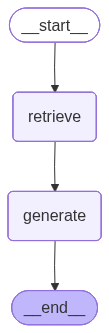

In [13]:
graph


### Code Explanation

This cell executes the defined LangGraph workflow (`graph`) using a specific test query. The `invoke` method runs the entire graph, passing the initial state (the user's query and an empty message list) to initiate the RAG process and retrieve the final structured result.


In [14]:
test_query = "How will EVS impact oil demand in the next decade?"

# Invoke the LangGraph workflow with the test query.
# The dictionary provides the initial state: 'query' is the user input,
# and 'messages' initializes the conversation history (empty list).
result = graph.invoke({"query": test_query, "messages": []})


In [15]:
print("=== GENERATED RESPONSE ===")
print(result["generation"])

=== GENERATED RESPONSE ===
Short answer
EV adoption will reduce oil demand by the 2020s, but the effect through 2030 is likely to be moderate and highly uncertain — not a near-term collapse of oil demand or prices.

Key points from the report
- Scale of EV growth: industry projections put EV shares of new passenger + light‑commercial vehicle sales at roughly 40–60% by 2030. The EV fleet is projected to grow from ~40 million today to roughly 300–500 million by the early 2030s.
- Fleet inertia: there are ~1.4 billion passenger vehicles today, ~90 million new vehicle sales per year, and vehicle lifetimes of ~15–20 years (often longer in developing markets). This means the ICE fleet cannot be fully replaced within a decade — fleet turnover limits near‑term displacement.
- Quantified demand impact: under OPEC’s central scenario EVs displace only about 2–3 million barrels per day (mbpd) of oil by 2030 and oil demand may not peak until the late 2030s. Other agencies (e.g., IEA) are more bulli

### Document Inspection

This cell iterates through the list of retrieved documents (`result["retrieved_docs"]`) and prints a formatted summary for each document. It extracts key metadata (source, page) and displays a truncated snippet of the content to allow the user to visually inspect what information was successfully retrieved by the RAG system.


In [16]:
print("\n=== RETRIEVED DOCUMENTS ===")
for i, doc in enumerate(result["retrieved_docs"], 1):
    source = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page", "?")
    snippet = doc.page_content[:500].replace("\n", " ")
    print(f"[{i}] Source: {source} | Page: {page}")
    print(f"    {snippet}...")


=== RETRIEVED DOCUMENTS ===
[1] Source: ../documents/evs_oil_price_shock.pdf | Page: 3
    Energy Agency, and McKinsey collectively project that EVs will account for between 40 and 60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which matters more than annual sales for oil displacement — is projected to grow from roughly 40 million vehicles today to between 300 and 500 million by the early 2030s. Whether this is sufficient to materially alter the oil price formation process is the central question this report addresses. 1.1 Scope and Methodology  This ...
[2] Source: ../documents/evs_oil_price_shock.pdf | Page: 7
    Will EVs Dampen the Oil Price Shock? Version 1.0 Research Report — For Educational and RAG Pipeline Use Page 8 4. EV Adoption Trajectories and Oil Demand Displacement  Projecting oil demand displacement from EV adoption requires integrating three distinct analytical layers: the annual sales trajectory for new EVs, the retirement rate of th

In [17]:
print(result["context"])

Energy Agency, and McKinsey collectively project that EVs will account for between 40 and
60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which
matters more than annual sales for oil displacement — is projected to grow from roughly 40
million vehicles today to between 300 and 500 million by the early 2030s. Whether this is
sufficient to materially alter the oil price formation process is the central question this report
addresses.
1.1 Scope and Methodology
 This report focuses on the relationship between passenger and light commercial vehicle
electrification and global oil demand dynamics. Heavy trucking, aviation, shipping, and
petrochemical feedstock demand — which collectively account for roughly 43 percent of oil
consumption — are not the primary subject of analysis, though their trajectories are

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand 